In [1]:
import pickle
import matplotlib.pyplot as plt
import japanize_matplotlib
import pywt
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm  # プログレスバー表示用

In [2]:
data_file_path = "../../data/bcidatasetIV2a/processed/merged.pkl"
# data_file_path = "../data/20250512/processed/ishii_merged.pkl"
data_file_path = "../../data/20250604/processed/20250604_1_ishii_ica_epochs.pkl"

In [3]:
# pickleのEEGデータを読み込む
with open(data_file_path, 'rb') as f:
    data = pickle.load(f)

epochs = data['epochs']  # EEGデータ
epochs_list = epochs.get_data()  # エポックデータ
labels = data['labels']  # ラベル
# drop_indices = data['drop_indices']  # 除外されたエポックのインデックス
fs = 2500

In [4]:
epochs_list.shape

(60, 63, 12501)

In [5]:
labels

array([1, 1, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1, 2, 1, 2, 2,
       2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1,
       2, 2, 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 2, 2, 1])

In [6]:
e0 = epochs_list[0, :, :]
e0c0 = epochs_list[0, 1, :]
e0c0

array([-6.61819783e-06, -6.67719987e-06, -6.72905247e-06, ...,
       -4.93273802e-06, -4.60791761e-06, -4.26894912e-06])

In [7]:
window_idx = 1
# window_data = e0c0[window_idx*fs:(window_idx+1)*fs]
windows_data = e0c0
print(windows_data.shape)

# e0c0をwavelet変換する
scales = np.arange(1, 64)
# Morlet waveletでCWT実行

coefficients, frequencies = pywt.cwt(windows_data, scales, 'cmor', 1/fs)

(12501,)


/home/neuron/Documents/mi-analyze/.venv/lib/python3.12/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


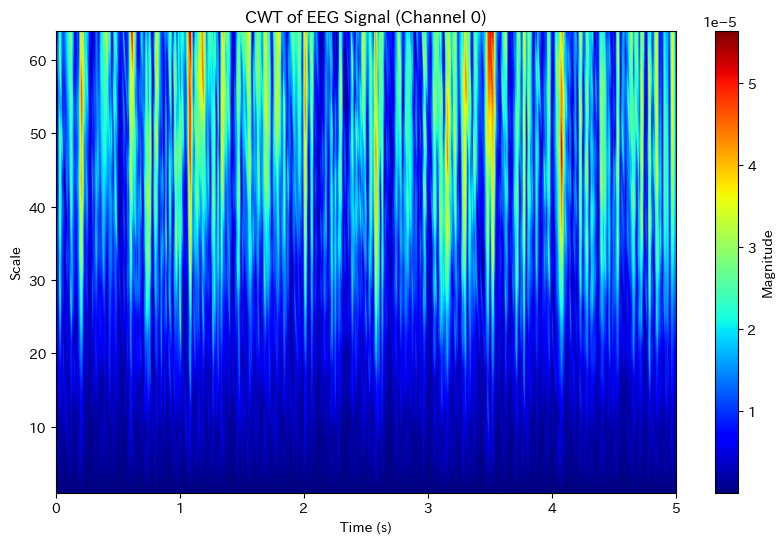

In [8]:
# Wavelet変換の結果をプロット
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(coefficients), aspect='auto', extent=[0*1/fs, len(windows_data)/fs-1/fs, 1, 64], cmap='jet', origin='lower')
plt.colorbar(label='Magnitude')
plt.title('CWT of EEG Signal (Channel 0)')
plt.xlabel('Time (s)')
plt.ylabel('Scale')
plt.show()

In [9]:
np.abs(coefficients)

array([[1.55072038e-06, 3.56459619e-07, 1.88340545e-08, ...,
        4.35009567e-07, 4.02672937e-07, 5.34585694e-07],
       [2.18404909e-06, 1.45704786e-06, 6.01165290e-07, ...,
        5.74388975e-07, 7.95430557e-07, 1.35343047e-06],
       [2.65579313e-06, 2.34764732e-06, 1.70815997e-06, ...,
        1.03031021e-06, 1.49352394e-06, 1.83123801e-06],
       ...,
       [4.24851800e-06, 4.16603918e-06, 4.18184931e-06, ...,
        1.03071720e-05, 1.02271286e-05, 1.01459086e-05],
       [7.02532001e-06, 7.35324369e-06, 7.70459979e-06, ...,
        1.00572214e-05, 9.98403226e-06, 9.90980969e-06],
       [1.03917659e-05, 1.05512924e-05, 1.06909428e-05, ...,
        9.70143654e-06, 9.61003485e-06, 9.52200770e-06]])

In [10]:
from tqdm import tqdm
import numpy as np
import pywt
import os
import pickle

# 全エポック、全チャンネル、全時間窓に対してwavelet変換を行う関数
def compute_wavelet_features_by_epoch(epochs_data, fs, output_dir, scales=np.arange(1, 64), wavelet='cmor', target_fs=10):
    """
    メモリ使用量を削減するためにエポックごとにCWT (Continuous Wavelet Transform)を計算し、
    結果を逐次ファイルに保存します。複素数の絶対値のみを保存します。
    結果を指定されたサンプリングレート(target_fs)にダウンサンプリングします。
    
    Parameters:
    -----------
    epochs_data : numpy.ndarray
        形状 (n_epochs, n_channels, n_times) のEEGデータ
    fs : float
        元のサンプリング周波数
    output_dir : str
        結果を保存するディレクトリのパス
    scales : array
        ウェーブレットのスケール
    wavelet : str
        使用するウェーブレット ('cmor' for Morlet)
    target_fs : float
        ダウンサンプリング後のサンプリングレート (Hz)
        
    Returns:
    --------
    wavelet_info : dict
        ウェーブレット変換のメタデータを含む辞書
    """
    n_epochs, n_channels, n_times = epochs_data.shape
    window_size = fs*3  # 6秒間の窓
    n_windows = n_times // window_size
    
    # ダウンサンプリングのための準備
    downsample_factor = int(fs / target_fs)
    downsampled_window_size = window_size // downsample_factor
    
    # 結果を保存するディレクトリが存在しない場合は作成
    os.makedirs(output_dir, exist_ok=True)
    
    # メタデータ情報を保存する辞書
    wavelet_info = {
        'frequencies': None,  # 周波数 (全窓共通)
        'scales': scales,     # スケール
        'original_fs': fs,    # 元のサンプリング周波数
        'target_fs': target_fs,  # ダウンサンプリング後のサンプリング周波数
        'downsample_factor': downsample_factor,  # ダウンサンプリング係数
        'original_window_size': window_size,  # 元の窓サイズ
        'downsampled_window_size': downsampled_window_size,  # ダウンサンプリング後の窓サイズ
        'shape': (n_epochs, n_channels, n_windows, len(scales), downsampled_window_size),  # 全体の形状
        'files': []  # 保存されたファイルのリスト
    }
    
    print(f"処理開始: {n_epochs}エポック, {n_channels}チャンネル, {n_windows}時間窓")
    print(f"ダウンサンプリング: {fs}Hz → {target_fs}Hz (係数: {downsample_factor})")
    
    # 各エポックについて処理
    for epoch_idx in tqdm(range(n_epochs), desc="エポックの処理"):
        # 現在のエポックの結果を保存する配列 (ダウンサンプリング後のサイズで)
        epoch_coeffs = np.zeros((n_channels, n_windows, len(scales), downsampled_window_size), dtype=float)
        
        # チャンネルと時間窓についてループ
        for channel_idx in range(n_channels):
            for window_idx in range(n_windows):
                # 現在の時間窓のデータを取得
                window_data = epochs_data[epoch_idx, channel_idx, window_idx*window_size:(window_idx+1)*window_size]
                
                # CWTを計算
                coeffs, freqs = pywt.cwt(window_data, scales, wavelet, 1/fs)
                
                # ダウンサンプリング (時間軸方向に間引き)
                downsampled_coeffs = coeffs[:, ::downsample_factor]
                
                # 結果を保存 (絶対値のみ)
                epoch_coeffs[channel_idx, window_idx] = np.abs(downsampled_coeffs)
                
                # 最初の計算で周波数を保存 (すべての計算で同じ)
                if wavelet_info['frequencies'] is None:
                    wavelet_info['frequencies'] = freqs
        
        # 現在のエポックの結果をファイルに保存
        epoch_file = os.path.join(output_dir, f"epoch_{epoch_idx:04d}.pkl")
        with open(epoch_file, 'wb') as f:
            pickle.dump(epoch_coeffs, f)
        
        # 保存したファイルをリストに追加
        wavelet_info['files'].append(epoch_file)
        
        # メモリを解放するために配列を削除
        del epoch_coeffs
    
    # メタデータ情報をファイルに保存
    metadata_file = os.path.join(output_dir, "wavelet_info.pkl")
    with open(metadata_file, 'wb') as f:
        pickle.dump(wavelet_info, f)
    
    print(f"処理完了: メタデータが {metadata_file} に保存されました")
    print(f"各エポックのwavelet係数は {output_dir} ディレクトリに保存されました")
    print(f"サンプリングレート: {target_fs}Hz, 時間窓のサイズ: {downsampled_window_size} サンプル")
    
    return wavelet_info


# 特定のエポックのwavelet係数を読み込む関数
def load_epoch_coefficients(wavelet_info, epoch_idx):
    """
    指定されたエポックのwavelet係数を読み込みます
    
    Parameters:
    -----------
    wavelet_info : dict
        compute_wavelet_features_by_epoch関数で生成されたメタデータ辞書
    epoch_idx : int
        読み込むエポックのインデックス
        
    Returns:
    --------
    coeffs : numpy.ndarray
        指定されたエポックのwavelet係数
    """
    if epoch_idx < 0 or epoch_idx >= len(wavelet_info['files']):
        raise ValueError(f"エポックインデックス{epoch_idx}は範囲外です (0-{len(wavelet_info['files'])-1})")
    
    # ファイルからエポックのデータを読み込む
    with open(wavelet_info['files'][epoch_idx], 'rb') as f:
        coeffs = pickle.load(f)
    
    return coeffs

In [11]:

# 結果を保存するディレクトリを作成
output_dir = "../data/20250512/processed/wavelet_features_50hz"

# エポックごとに処理してファイルに保存
# ダウンサンプリングして10Hzにする
wavelet_info = compute_wavelet_features_by_epoch(epochs_list[:228], fs, output_dir, target_fs=25)

処理開始: 60エポック, 63チャンネル, 1時間窓
ダウンサンプリング: 2500Hz → 25Hz (係数: 100)


エポックの処理:   0%|          | 0/60 [00:00<?, ?it/s]

エポックの処理: 100%|██████████| 60/60 [03:39<00:00,  3.66s/it]

処理完了: メタデータが ../data/20250512/processed/wavelet_features_50hz/wavelet_info.pkl に保存されました
各エポックのwavelet係数は ../data/20250512/processed/wavelet_features_50hz ディレクトリに保存されました
サンプリングレート: 25Hz, 時間窓のサイズ: 75 サンプル


In [12]:
# メタデータの確認
print("Wavelet metadata:")
print(f"Number of epochs: {len(wavelet_info['files'])}")
print(f"Frequencies: {wavelet_info['frequencies']}")
print(f"Original data shape: {wavelet_info['shape']}")
print(f"Original sampling rate: {wavelet_info['original_fs']} Hz")
print(f"Target sampling rate: {wavelet_info['target_fs']} Hz")
print(f"Downsample factor: {wavelet_info['downsample_factor']}")
print(f"Original window size: {wavelet_info['original_window_size']} samples")
print(f"Downsampled window size: {wavelet_info['downsampled_window_size']} samples")

Wavelet metadata:
Number of epochs: 60
Frequencies: [1250.          625.          416.66666667  312.5         250.
  208.33333333  178.57142857  156.25        138.88888889  125.
  113.63636364  104.16666667   96.15384615   89.28571429   83.33333333
   78.125        73.52941176   69.44444444   65.78947368   62.5
   59.52380952   56.81818182   54.34782609   52.08333333   50.
   48.07692308   46.2962963    44.64285714   43.10344828   41.66666667
   40.32258065   39.0625       37.87878788   36.76470588   35.71428571
   34.72222222   33.78378378   32.89473684   32.05128205   31.25
   30.48780488   29.76190476   29.06976744   28.40909091   27.77777778
   27.17391304   26.59574468   26.04166667   25.51020408   25.
   24.50980392   24.03846154   23.58490566   23.14814815   22.72727273
   22.32142857   21.92982456   21.55172414   21.18644068   20.83333333
   20.49180328   20.16129032   19.84126984]
Original data shape: (60, 63, 1, 63, 75)
Original sampling rate: 2500 Hz
Target sampling rate: 25

In [13]:
# 特定のエポック、チャンネル、時間窓の結果を可視化
epoch_idx = 0
channel_idx = 2  # 元のe0c0と同じチャンネルを使用
window_idx = 1   # 元の例と同じ時間窓を使用

# 指定したエポックのwavelet係数を読み込む込む
epoch_coeffs = load_epoch_coefficients(wavelet_info, epoch_idx)

# 指定したチャンネルと時間窓のwavelet係数を取得
coeffs = epoch_coeffs[channel_idx, window_idx]

# 可視化 (時間軸はダウンサンプリング後のサンプリングレートで調整)
plt.figure(figsize=(10, 6))
plt.imshow(coeffs, aspect='auto', 
          extent=[0, wavelet_info['downsampled_window_size']/wavelet_info['target_fs'], 1, len(wavelet_info['scales'])], 
          cmap='jet', origin='lower')
plt.colorbar(label='Magnitude')
plt.title(f'CWT of EEG Signal (Epoch {epoch_idx}, Channel {channel_idx}, Window {window_idx})')
plt.xlabel('Time (s)')
plt.ylabel('Scale')
plt.show()

# 元のサンプリングレートと比較
print(f"元のサンプリングレート: {wavelet_info['original_fs']} Hz")
print(f"ダウンサンプリング後のレート: {wavelet_info['target_fs']} Hz")
print(f"元の時間窓の長さ: {wavelet_info['original_window_size']/wavelet_info['original_fs']:.2f} 秒")
print(f"ダウンサンプリング後の時間窓の長さ: {wavelet_info['downsampled_window_size']/wavelet_info['target_fs']:.2f} 秒")

IndexError: index 1 is out of bounds for axis 1 with size 1

In [ ]:
import os
import pickle

# 結果をpickleファイルとして保存
output_file_path = "../../data/bcidatasetIV2a/processed/wavelet_features_50.pkl"

# pickleとして保存
with open(output_file_path, 'wb') as f:
    pickle.dump(wavelet_info, f)
    
print(f"wawvelet特徴量が {output_file_path} に保存されました")

# メタデータファイルのパスを確認
metadata_file = os.path.join(output_dir, "wavelet_info.pkl")
print(f"メタデータファイル: {metadata_file}")

# 各エポックのファイルを確認
print(f"最初の数個のエポックファイル: {wavelet_info['files'][:3]}...")

wawvelet特徴量が ../../data/bcidatasetIV2a/processed/wavelet_features_50.pkl に保存されました
メタデータファイル: ../data/20250512/processed/wavelet_features_50hz/wavelet_info.pkl
最初の数個のエポックファイル: ['../data/20250512/processed/wavelet_features_50hz/epoch_0000.pkl', '../data/20250512/processed/wavelet_features_50hz/epoch_0001.pkl', '../data/20250512/processed/wavelet_features_50hz/epoch_0002.pkl']...


In [ ]:
# 保存したデータを読み込んで確認（オプショナル）
with open(output_file_path, 'rb') as f:
    loaded_features = pickle.load(f)

print("Loaded wavelet features shape:", loaded_features['coefficients'].shape)
print("Shape matches original:", loaded_features['coefficients'].shape == wavelet_features['coefficients'].shape)

# 別のエポックを読み込んで確認
# 前のセルとは別のエポックを読み込む
epoch_idx = 1  # 別のエポックを選択

# 指定したエポックのwavelet係数を読み込む
epoch_coeffs = load_epoch_coefficients(wavelet_info, epoch_idx)

print(f"Epoch {epoch_idx} coefficients shape: {epoch_coeffs.shape}")

# 別のチャンネルと時間窓を可視化
channel_idx = 3  # 別のチャンネル
window_idx = 0  # 別の時間窓

# 可視化
plt.figure(figsize=(10, 6))
plt.imshow(epoch_coeffs[channel_idx, window_idx], aspect='auto', 
          extent=[0, wavelet_info['window_size']/fs, 1, len(wavelet_info['scales'])], 
          cmap='jet', origin='lower')
plt.colorbar(label='Magnitude')
plt.title(f'CWT of EEG Signal (Epoch {epoch_idx}, Channel {channel_idx}, Window {window_idx})')
plt.xlabel('Time (s)')
plt.ylabel('Scale')
plt.show()

KeyError: 'coefficients'

In [ ]:
# 保存されたメタデータファイルを読み込んで確認
# 別のセッションでもデータにアクセスできることを確認
metadata_file = os.path.join(output_dir, "wavelet_info.pkl")
with open(metadata_file, 'rb') as f:
    loaded_info = pickle.load(f)

print("Loaded metadata:")
print(f"Number of epochs: {len(loaded_info['files'])}")
print(f"Original data shape: {loaded_info['shape']}")
print(f"Original sampling rate: {loaded_info['original_fs']} Hz")
print(f"Target sampling rate: {loaded_info['target_fs']} Hz")
print(f"Downsample factor: {loaded_info['downsample_factor']}")

# 読み込んだメタデータからエポックを読み込む
epoch_idx = 2  # 別のエポックを選択
epoch_coeffs = load_epoch_coefficients(loaded_info, epoch_idx)
print(f"Successfully loaded epoch {epoch_idx} from saved metadata")
print(f"Loaded coefficients shape: {epoch_coeffs.shape}")

In [ ]:
# 複数のエポックを連続して読み込む例
# 実際の分析で必要な場合に使用する方法
print("Loading multiple epochs sequentially:")

from tqdm.notebook import tqdm

# 最初の5エポックをテストとして読み込む
num_epochs_to_load = min(5, len(loaded_info['files']))

# 特定のチャンネルと時間窓の値を収集する例
channel_idx = 2
window_idx = 1
all_values = []

for epoch_idx in tqdm(range(num_epochs_to_load), desc="エポックを読み込み中"):
    # エポックを読み込む
    epoch_coeffs = load_epoch_coefficients(loaded_info, epoch_idx)
    
    # 特定のチャンネルと時間窓の値を取得
    values = epoch_coeffs[channel_idx, window_idx]
    
    # 値を保存
    all_values.append(values)
    
    # メモリを解放
    del epoch_coeffs

# 収集した値の形状を確認
all_values = np.array(all_values)
print(f"Collected values shape: {all_values.shape}")

# 結果を複数のエポックで比較する例
plt.figure(figsize=(12, 8))
for i in range(min(3, len(all_values))):
    plt.subplot(3, 1, i+1)
    plt.imshow(all_values[i], aspect='auto', 
              extent=[0, loaded_info['downsampled_window_size']/loaded_info['target_fs'], 1, len(loaded_info['scales'])], 
              cmap='jet', origin='lower')
    plt.colorbar(label='Magnitude')
    plt.title(f'CWT of EEG Signal (Epoch {i}, Channel {channel_idx}, Window {window_idx})')
    plt.xlabel('Time (s)')
    plt.ylabel('Scale')
plt.tight_layout()
plt.show()